In [83]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import powerlaw

- Part B - Data Analysis & Testing tasks:

In [4]:
df = pd.read_csv("spread_locator_dataset - spread_locator_dataset.csv.csv")

1. Fit the data to Bernoulli and Binomial distribution (transaction occurance & weekly count).

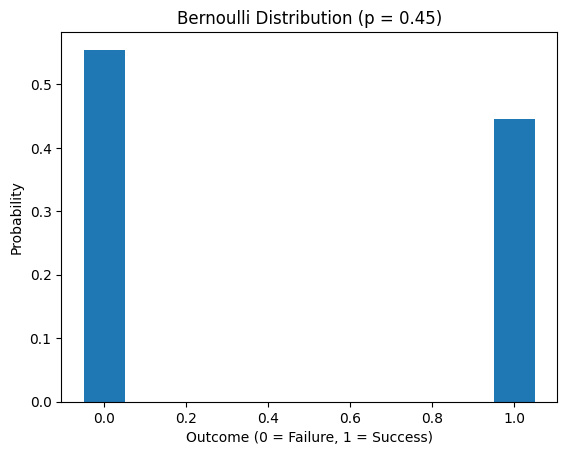

Probability of success (p): 0.45
Probability of failure (1-p): 0.55


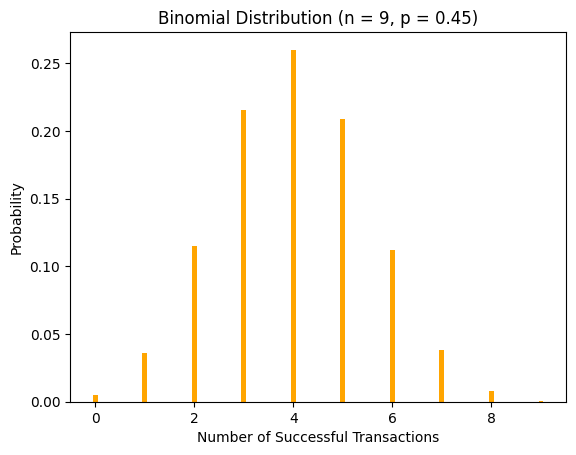

Probability of 0 successful transactions: 0.0050
Probability of 1 successful transactions: 0.0359
Probability of 2 successful transactions: 0.1152
Probability of 3 successful transactions: 0.2159
Probability of 4 successful transactions: 0.2602
Probability of 5 successful transactions: 0.2090
Probability of 6 successful transactions: 0.1119
Probability of 7 successful transactions: 0.0385
Probability of 8 successful transactions: 0.0077
Probability of 9 successful transactions: 0.0007


In [61]:
# convert transaction_status column's values are in numeric form
df["transaction_outcome"] = np.where(df["transaction_status"]=="Success",1,0)

# calculate the mean of success
p = df["transaction_outcome"].mean()

# fit the bernoulli dist.
rv = sp.stats.bernoulli(p)

# Step 4: Generate and plot the probability mass function (PMF) for the Bernoulli distribution
x = [0, 1]  # The two possible outcomes (Failure = 0, Success = 1)
pmf = rv.pmf(x)

# Plot the PMF
plt.bar(x, pmf, width=0.1)
plt.xlabel('Outcome (0 = Failure, 1 = Success)')
plt.ylabel('Probability')
plt.title(f'Bernoulli Distribution (p = {p:.2f})')
plt.show()

# Step 5: Print the probability of success (p) and failure (1-p)
print(f'Probability of success (p): {p:.2f}')
print(f'Probability of failure (1-p): {1 - p:.2f}')


n = df['transaction_count'].max()  # Maximum number of trials (transactions per customer)
binom_rv = sp.stats.binom(n, p)

# Step 7: Generate and plot the PMF for Binomial distribution
binom_x = list(range(n + 1))  # Possible number of successful transactions (0 to n)
binom_pmf = binom_rv.pmf(binom_x)

# Plot the PMF for Binomial
plt.bar(binom_x, binom_pmf, color='orange', width=0.1)
plt.xlabel('Number of Successful Transactions')
plt.ylabel('Probability')
plt.title(f'Binomial Distribution (n = {n}, p = {p:.2f})')
plt.show()

# Step 8: Print the probability mass function for Binomial distribution at each possible outcome
for x_val, prob in zip(binom_x, binom_pmf):
    print(f'Probability of {x_val} successful transactions: {prob:.4f}')

2. Fit the data to poisson distribution (number of transactions per day).

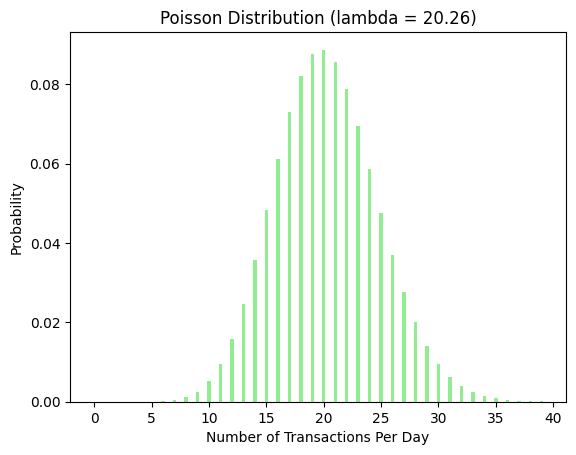

Probability of 0 transactions per day: 0.0000
Probability of 1 transactions per day: 0.0000
Probability of 2 transactions per day: 0.0000
Probability of 3 transactions per day: 0.0000
Probability of 4 transactions per day: 0.0000
Probability of 5 transactions per day: 0.0000
Probability of 6 transactions per day: 0.0002
Probability of 7 transactions per day: 0.0004
Probability of 8 transactions per day: 0.0011
Probability of 9 transactions per day: 0.0025
Probability of 10 transactions per day: 0.0051
Probability of 11 transactions per day: 0.0094
Probability of 12 transactions per day: 0.0159
Probability of 13 transactions per day: 0.0247
Probability of 14 transactions per day: 0.0358
Probability of 15 transactions per day: 0.0484
Probability of 16 transactions per day: 0.0612
Probability of 17 transactions per day: 0.0730
Probability of 18 transactions per day: 0.0821
Probability of 19 transactions per day: 0.0876
Probability of 20 transactions per day: 0.0887
Probability of 21 trans

In [77]:
# Step 1: Aggregate the data by 'transaction_date' to get the total number of transactions per day
daily_transactions = df.groupby('transaction_date')['transaction_count'].sum()

# Step 2: Calculate the mean (lambda) of daily transactions for Poisson distribution
lambda_value = daily_transactions.mean()

# Step 3: Fit the Poisson distribution using the calculated lambda
poisson_rv = sp.stats.poisson(lambda_value)

# Step 4: Generate and plot the probability mass function (PMF) for Poisson distribution
x = range(0, int(daily_transactions.max()) + 1)  # Possible number of transactions per day (0 to max)
poisson_pmf = poisson_rv.pmf(x)

# Plot the PMF for Poisson
plt.bar(x, poisson_pmf, color='lightgreen', width=0.3)
plt.xlabel('Number of Transactions Per Day')
plt.ylabel('Probability')
plt.title(f'Poisson Distribution (lambda = {lambda_:.2f})')
plt.show()

# Step 5: Print the probability of each possible number of transactions per day
for transaction_count, prob in zip(x, poisson_pmf):
    print(f'Probability of {transaction_count} transactions per day: {prob:.4f}')

3. Model transaction amounts using log-normal and power law distributions.

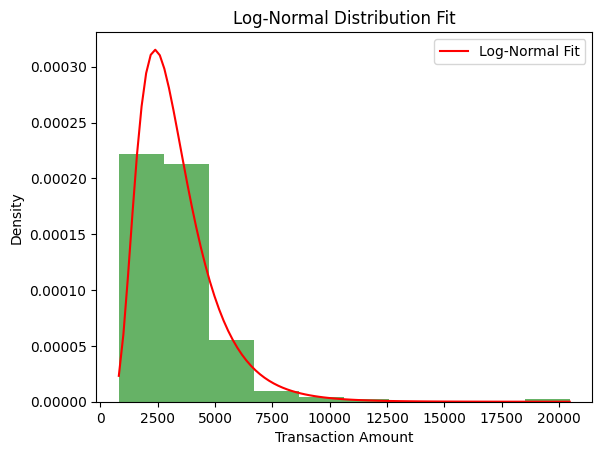

Calculating best minimal value for power law fit


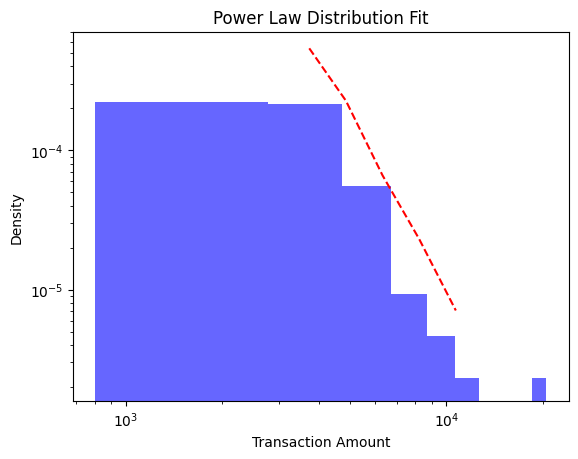

Log-Normal Parameters: Shape = 0.47, Loc = 0.00, Scale = 2983.16
Power Law Exponent: 4.15


In [84]:
# Step 1: Fit the Log-Normal distribution
# First, we take the log of the transaction amounts to see if it follows a normal distribution
log_transaction_amounts = np.log(df['transaction_amount'])

# Fit a Log-Normal distribution to the data
shape, loc, scale = sp.stats.lognorm.fit(df['transaction_amount'], floc=0)  # Fit Log-Normal

# Step 2: Plot the histogram of the transaction amounts and overlay the Log-Normal PDF
x = np.linspace(min(df['transaction_amount']), max(df['transaction_amount']), 100)
lognorm_pdf = sp.stats.lognorm.pdf(x, shape, loc, scale)

plt.hist(df['transaction_amount'], bins=10, density=True, alpha=0.6, color='g')
plt.plot(x, lognorm_pdf, color='r', label='Log-Normal Fit')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.title('Log-Normal Distribution Fit')
plt.legend()
plt.show()

# Step 3: Fit the Power Law distribution using the powerlaw package
# Fit the Power Law distribution to the transaction amounts
power_law = powerlaw.Fit(df['transaction_amount'])

# Step 4: Plot the Power Law PDF
plt.hist(df['transaction_amount'], bins=10, density=True, alpha=0.6, color='b')
power_law.plot_pdf(color='r', linestyle='--')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.title('Power Law Distribution Fit')
plt.show()

# Step 5: Print the parameters and the goodness-of-fit results for both distributions
print(f"Log-Normal Parameters: Shape = {shape:.2f}, Loc = {loc:.2f}, Scale = {scale:.2f}")
print(f"Power Law Exponent: {power_law.alpha:.2f}")

4. Generate and interpret Q-Q plot to test normality.

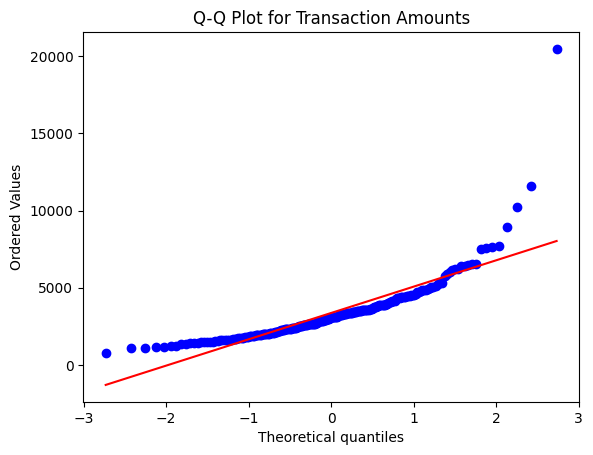

In [86]:
# Step 1: Generate the Q-Q plot to check for normality
sp.stats.probplot(df['transaction_amount'], dist="norm", plot=plt)

# Step 2: Display the plot
plt.title('Q-Q Plot for Transaction Amounts')
plt.show()

- How to Interpret the Q-Q Plot:
- If the points bend away from the line, the data may be skewed (either positively or negatively).

5. Apply box-cox transformation to stablize variance.

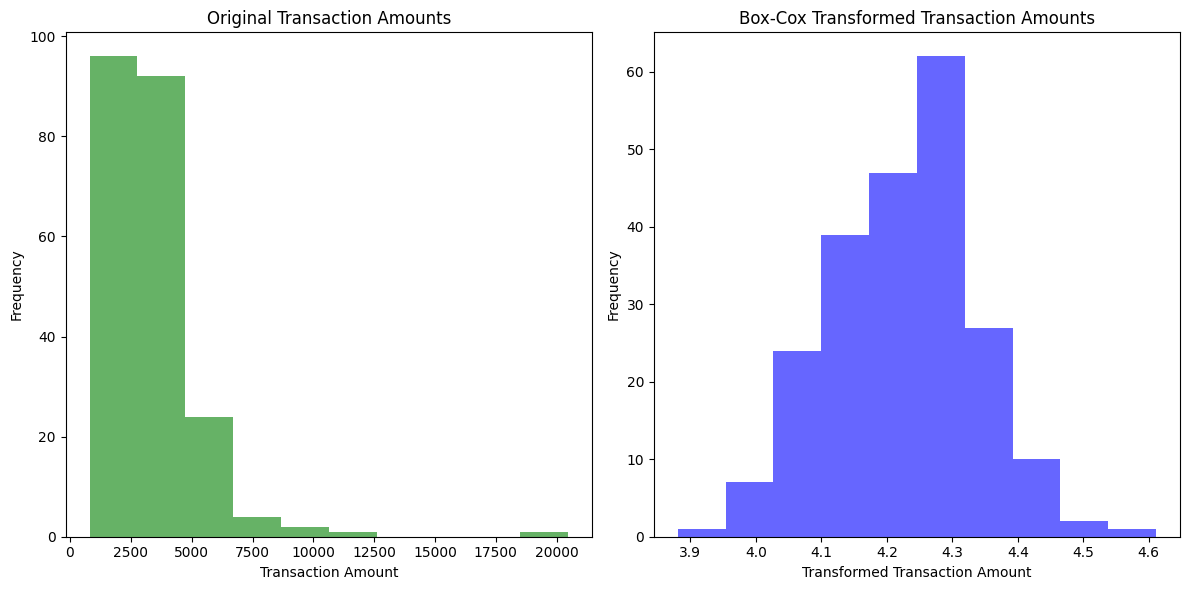

Box-Cox Transformation Lambda: -0.18


In [91]:
# Step 1: Apply the Box-Cox transformation (it only works for positive data)
df['transaction_amount_boxcox'], lambda_value = sp.stats.boxcox(df['transaction_amount'])

# Step 2: Visualize the original and transformed data (Box-Cox)
plt.figure(figsize=(12, 6))

# Plot original transaction amounts
plt.subplot(1, 2, 1)
plt.hist(df['transaction_amount'], bins=10, color='g', alpha=0.6)
plt.title('Original Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

# Plot transformed transaction amounts (Box-Cox)
plt.subplot(1, 2, 2)
plt.hist(df['transaction_amount_boxcox'], bins=10, color='b', alpha=0.6)
plt.title('Box-Cox Transformed Transaction Amounts')
plt.xlabel('Transformed Transaction Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Step 3: Print the Box-Cox transformation parameter (lambda)
print(f"Box-Cox Transformation Lambda: {lambda_:.2f}")

6. Calculate Z-scores for transaction amounts and compute probability of transactions exceeding 5000 rupees.

Z-score for ₹5000: 0.82
Probability of a transaction exceeding ₹5000: 0.2052


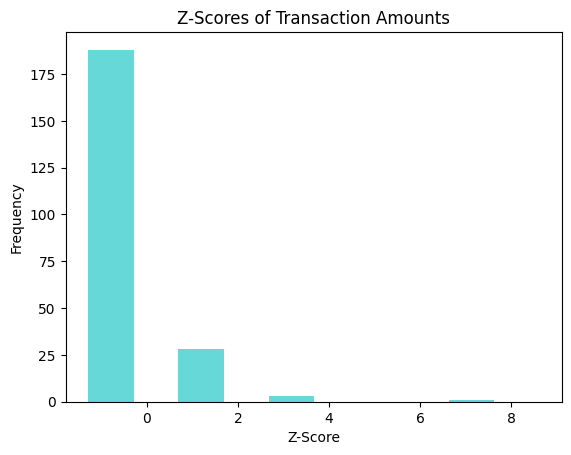

In [97]:
# Step 1: Calculate the Z-scores for the transaction amounts
mean = df['transaction_amount'].mean()
std_dev = df['transaction_amount'].std()
df['z_score'] = (df['transaction_amount'] - mean) / std_dev

# Step 2: Compute the Z-score for ₹5000
z_5000 = (5000 - mean) / std_dev
print(f"Z-score for ₹5000: {z_5000:.2f}")

# Step 3: Compute the probability of a transaction exceeding ₹5000
# Use the CDF of the normal distribution to find the probability
# The CDF gives the probability of a transaction being less than ₹5000, so we subtract it from 1
probability_above_5000 = 1 - sp.stats.norm.cdf(5000, mean, std_dev)
print(f"Probability of a transaction exceeding ₹5000: {probability_above_5000:.4f}")

# Step 4: Plot the Z-scores
plt.hist(df['z_score'], bins=5, color='c', alpha=0.6, width=1)
plt.title('Z-Scores of Transaction Amounts')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.show()

7. Plot and interpret PDF and CDF for transaction amounts.

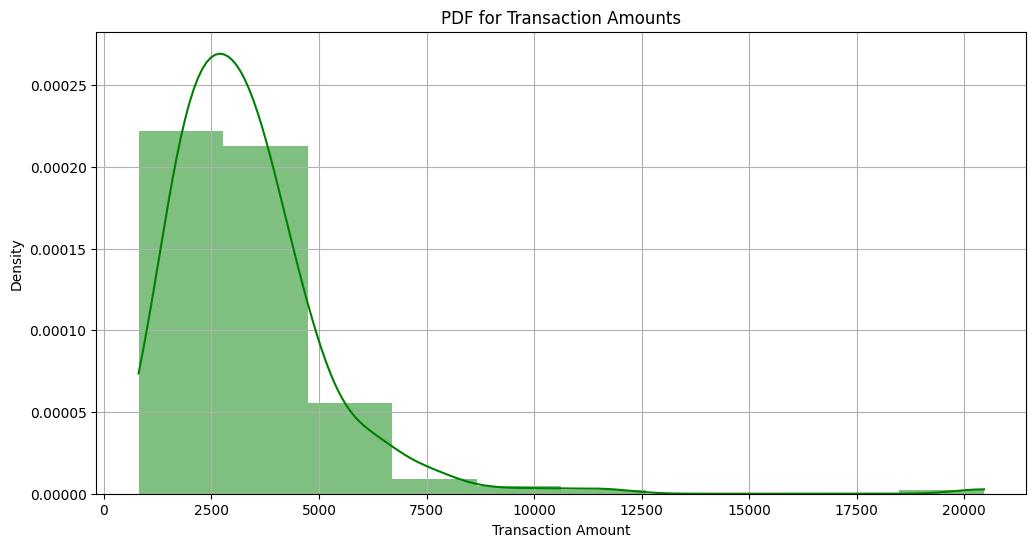

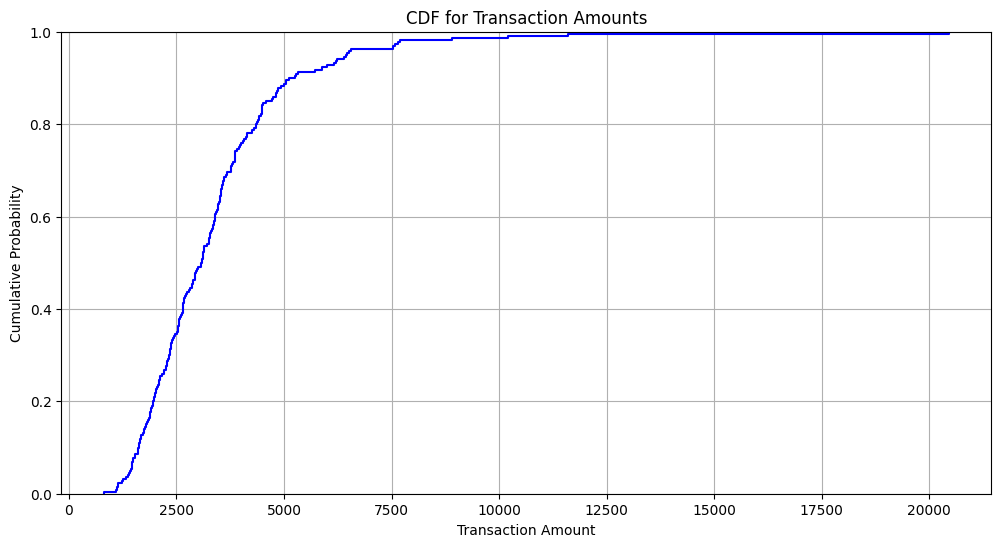

In [102]:
# Step 1: Plot the PDF (Probability Density Function) for transaction amounts
plt.figure(figsize=(12, 6))

# Plotting the histogram (PDF)
sns.histplot(df['transaction_amount'], kde=True, color='green', bins=10, stat='density', linewidth=0)
plt.title('PDF for Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.grid(True)

plt.show()

# Step 2: Plot the CDF (Cumulative Distribution Function) for transaction amounts
plt.figure(figsize=(12, 6))

# Plotting the CDF
sns.ecdfplot(df['transaction_amount'], color='blue')
plt.title('CDF for Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Cumulative Probability')
plt.grid(True)

plt.show()

- PDF Plot:
    - Peak: Most transactions fall within a certain range around the peak.
    - Right Tail: Larger transactions exist but occur less frequently.
    - Flat Areas: Very few transactions happen outside the peak range.

- CDF Plot:
    - Steep Rise: Most transactions occur at lower amounts.
    - Flat End: Cumulative probability plateaus, indicating few large transactions beyond a certain threshold.

8. Conclude which distribution best fits the dataset and justify insights for decision-making.